# BO v7 — 3-D Publication Heatmaps

Five 3-D surfaces over the feasible composition simplex: GP posterior mean at the 18/24/30-point campaign stages, and UCB acquisition (Initial→R3, R3→R4). GPs are loaded pre-trained from `models/BO/`.

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from mltoolkit.acquisition.functions import upper_confidence_bound
from matsci_ml.config import FEATURE_COLS
from matsci_ml import PyTorchANNTrainer, set_all_seeds
from utils.scatter import scatter_by_mass

fm.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

RANDOM_SEED = 42
MODEL_DIR = 'models/all_properties'
NORM_TO_MG = 31.0
MASS_LOADINGS = [15, 20]

set_all_seeds(RANDOM_SEED)
os.makedirs('plots/bo', exist_ok=True)

df = pd.read_csv('data/mustard_fresh_weight.csv')

UCB_BETA_R3 = 13
UCB_BETA_R4 = 10
print(f"v7 trial #700: UCB beta_R3={UCB_BETA_R3}, beta_R4={UCB_BETA_R4}")

v7 trial #700: UCB beta_R3=13, beta_R4=10


In [ ]:
# Feasibility models + 3-D feasible simplex grids per mass loading
svc_grade = joblib.load(f'{MODEL_DIR}/svc_grade.pkl')
scaler_grade = joblib.load(f'{MODEL_DIR}/scaler_grade.pkl')
svr_water = joblib.load(f'{MODEL_DIR}/svr_water.pkl')
scaler_water = joblib.load(f'{MODEL_DIR}/scaler_water.pkl')
target_scaler_water = joblib.load(f'{MODEL_DIR}/target_scaler_water.pkl')
ann_stress = PyTorchANNTrainer().load(f'{MODEL_DIR}/ann_stress.pt')
scaler_stress_ann = joblib.load(f'{MODEL_DIR}/scaler_stress_ann.pkl')
target_scaler_stress_ann = joblib.load(f'{MODEL_DIR}/target_scaler_stress_ann.pkl')

N_GRID = 201   # simplex grid resolution per axis (step = 1/(N_GRID-1))


def make_feasible_grid_3d(mass_loading, n_grid=N_GRID):
    """Feasible compositions over the simplex (ALG, PVA, GUM free; CMC = 1 - rest),
    filtered by the grade/water/stress models. Returns X in FEATURE_COLS order."""
    ax = np.linspace(0, 1, n_grid)
    ALG, PVA, GUM = np.meshgrid(ax, ax, ax, indexing='ij')
    alg, pva, gum = ALG.ravel(), PVA.ravel(), GUM.ravel()
    keep = (alg + pva + gum) <= 1.0 + 1e-9
    alg, pva, gum = alg[keep], pva[keep], gum[keep]
    cmc = np.clip(1.0 - alg - pva - gum, 0, 1)
    X_raw = np.column_stack([gum, alg, pva, cmc,
                             np.full_like(alg, mass_loading)])       # [GUM, ALG, PVA, CMC, ML]
    X_g = X_raw.copy()
    X_g[:, 4] = scaler_grade.transform(X_g[:, 4].reshape(-1, 1)).ravel()
    grade_pred = svc_grade.predict(X_g)
    X_w = X_raw.copy()
    X_w[:, 4] = scaler_water.transform(X_w[:, 4].reshape(-1, 1)).ravel()
    water_pred = np.clip(target_scaler_water.inverse_transform(
        svr_water.predict(X_w).reshape(-1, 1)).ravel(), 0, 1)
    X_s = scaler_stress_ann.transform(X_raw.copy())
    stress_pred = target_scaler_stress_ann.inverse_transform(
        ann_stress.predict(X_s).reshape(-1, 1)).ravel()
    feasible = (grade_pred == True) & (water_pred >= 0.50) & (stress_pred >= 1.0)
    print(f"  ML={mass_loading}: {feasible.sum():,} feasible / {keep.sum():,} valid compositions")
    return X_raw[feasible]


print(f"Building 3-D feasible grids (N_GRID={N_GRID}):")
grids_3d = {ml: make_feasible_grid_3d(ml) for ml in MASS_LOADINGS}

# Experiment anchor
mgal_row = df.loc[df['ID'] == 'MGAL_0608'].iloc[0]
MGAL_0608 = dict(ALG=float(mgal_row['ALG']), PVA=float(mgal_row['PVA']),
                 GUM=float(mgal_row['GUM']), ML=int(mgal_row['MassLoading']))
print(f"\nMGAL_0608: {MGAL_0608}")

In [3]:
# Load the pre-trained v7 GP at each campaign stage (18 / 24 / 30 pts)
gp_stages = {tag: joblib.load(f'models/BO/gp_{tag}_v7pub3d.pkl')
             for tag in ['18pts', '24pts', '30pts']}
gp_init, gp_r3, gp_r4 = gp_stages['18pts'], gp_stages['24pts'], gp_stages['30pts']
for tag, gp in gp_stages.items():
    print(f"  {tag}: {gp.kernel_}")


  18pts: RBF(length_scale=[0.103, 0.103, 0.952, 9.24, 0.404]) + WhiteKernel(noise_level=0.134)
  24pts: RBF(length_scale=[0.103, 0.136, 9.24, 9.24, 3.59]) + WhiteKernel(noise_level=0.0565)
  30pts: RBF(length_scale=[0.103, 9.24, 9.24, 9.24, 0.113]) + WhiteKernel(noise_level=0.344)


In [ ]:
# 3-D render helpers
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

TICK_FS = 20
AXLABEL_FS = 20
CBAR_TICK_FS = 20
CBAR_LABEL_FS = 20
AXLABEL_PAD = 14
TICK_PAD = 4

# Composition simplex; CMC is implicit (= 1 - ALG - PVA - GUM)
_SIMPLEX_VERTS = {'ALG': (1.0, 0.0, 0.0), 'PVA': (0.0, 1.0, 0.0),
                  'GUM': (0.0, 0.0, 1.0), 'CMC': (0.0, 0.0, 0.0)}
_SIMPLEX_FACES = [['PVA', 'GUM', 'CMC'],   # ALG = 0 face
                  ['ALG', 'GUM', 'CMC'],   # PVA = 0 face
                  ['ALG', 'PVA', 'CMC'],   # GUM = 0 face
                  ['ALG', 'PVA', 'GUM']]   # CMC = 0 face
# GUM--ALG edge omitted: it cuts across the front of the feasible cloud
_SIMPLEX_EDGES = [('ALG', 'PVA'), ('ALG', 'CMC'),
                  ('PVA', 'GUM'), ('PVA', 'CMC'), ('GUM', 'CMC')]


def _add_simplex_envelope(ax, face_rgba=(0.7, 0.7, 0.7, 0.50),
                          edge_rgba=(0.70, 0.70, 0.70, 0.80), lw=0.5):
    """Translucent light-gray shell of the full composition simplex, drawn behind the
    feasible cloud (zorder=0) so the colored cloud reads as a subset."""
    faces = [[_SIMPLEX_VERTS[v] for v in f] for f in _SIMPLEX_FACES]
    shell = Poly3DCollection(faces, facecolors=[face_rgba], edgecolors='none')
    shell.set_zorder(0)
    ax.add_collection3d(shell)

    segs = [[_SIMPLEX_VERTS[a], _SIMPLEX_VERTS[b]] for a, b in _SIMPLEX_EDGES]
    frame = Line3DCollection(segs, colors=[edge_rgba], linewidths=lw)
    frame.set_zorder(0)
    ax.add_collection3d(frame)


def render_surface_3d(values_by_ml, cmap, vmin, vmax, cbar_label, fname,
                      cbar_ticks=None, mark_max=True, mark_0608=True,
                      elev=22, azim=-60):
    """values_by_ml: {ml: 1-D array aligned to grids_3d[ml] rows}."""
    frames = []
    for ml in MASS_LOADINGS:
        X = grids_3d[ml]                       # [GUM, ALG, PVA, CMC, ML]
        frames.append(pd.DataFrame({
            'ALG': X[:, 1], 'PVA': X[:, 2], 'GUM': X[:, 0],
            'MassLoading': ml, 'value': values_by_ml[ml],
        }))
    plot_df = pd.concat(frames, ignore_index=True)

    sc = scatter_by_mass(
        MASS_LOADINGS, plot_df, x_var='ALG', y_var='PVA', z_var='GUM',
        y_col='value', vmin=vmin, vmax=vmax, cmap=cmap,
        s=5, alpha=0.05, edgecolor='none', rasterized=True,
        elev=elev, azim=azim, show_cbar=False, show_labels=False, show_ticks=True,
        figsize=(9 * len(MASS_LOADINGS), 5),
    )

    fig = plt.gcf()
    axes3d = [a for a in fig.axes if hasattr(a, 'zaxis')]
    for ax, ml in zip(axes3d, MASS_LOADINGS):
        ax.computed_zorder = False   # honor manual zorder so markers sit above the cloud
        _add_simplex_envelope(ax)
        ax.set_xlabel('ALG (%)', fontsize=AXLABEL_FS, labelpad=AXLABEL_PAD)
        ax.set_ylabel('PVA (%)', fontsize=AXLABEL_FS, labelpad=AXLABEL_PAD)
        ax.set_zlabel('GUM (%)', fontsize=AXLABEL_FS, labelpad=AXLABEL_PAD, rotation=90)
        ax.tick_params(axis='both', labelsize=TICK_FS, pad=TICK_PAD)
        if mark_max:
            X, v = grids_3d[ml], values_by_ml[ml]
            i = int(np.argmax(v))
            ax.scatter([X[i, 1]], [X[i, 2]], [X[i, 0]], marker='D', s=150,
                       color='magenta', edgecolor='white', linewidths=1.6,
                       zorder=20, depthshade=False)
        if mark_0608 and MGAL_0608['ML'] == ml:
            ax.scatter([MGAL_0608['ALG']], [MGAL_0608['PVA']], [MGAL_0608['GUM']],
                       marker='*', s=460, color='#39ff14', edgecolor='black',
                       linewidths=1.4, zorder=25, depthshade=False)

    # Right-hand gap for a single shared colorbar, clear of the GUM axis label
    fig.subplots_adjust(left=0.02, right=0.80, top=0.95, bottom=0.06, wspace=0.02)
    cax = fig.add_axes([0.88, 0.20, 0.018, 0.60])
    # Full-opacity mappable so the bar shows solid color regardless of cloud alpha
    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cax, ticks=cbar_ticks)
    cb.set_label(cbar_label, fontsize=CBAR_LABEL_FS)
    cb.ax.tick_params(labelsize=CBAR_TICK_FS, width=1.2, length=5)

    fig.savefig(f'plots/bo/{fname}', format='svg', dpi=200,
                bbox_inches='tight', pad_inches=0.15, transparent=False)
    plt.show()


# Fixed color scales (shared with the 2-D v7_pub notebook)
GP_VMIN, GP_VMAX, GP_TICKS = 30.0, 60.0, [30, 40, 50, 60]
# Init UCB (beta=13) is sigma-dominated and saturates high, so it uses the wider bar
UCB_VMIN = 60.0
UCB_VMAX_INIT, UCB_TICKS_INIT = 105.0, [60, 75, 90, 105]
UCB_VMAX_R3, UCB_TICKS_R3 = 100.0, [60, 70, 80, 90, 100]

In [ ]:
# GP posterior mean per stage; report observed range vs fixed color scale
def gp_mean_by_ml(gp):
    out = {}
    for ml in MASS_LOADINGS:
        out[ml] = gp.predict(grids_3d[ml]) * NORM_TO_MG
    return out

gp_mean_stage = {tag: gp_mean_by_ml(gp) for tag, gp in gp_stages.items()}
_allmu = np.concatenate([v for s in gp_mean_stage.values() for v in s.values()])
print(f"GP mean observed range over feasible grid: [{_allmu.min():.1f}, {_allmu.max():.1f}] mg/cm^2")
print(f"  Fixed color scale [{GP_VMIN}, {GP_VMAX}] (values outside are clipped in color)")

## GP posterior mean

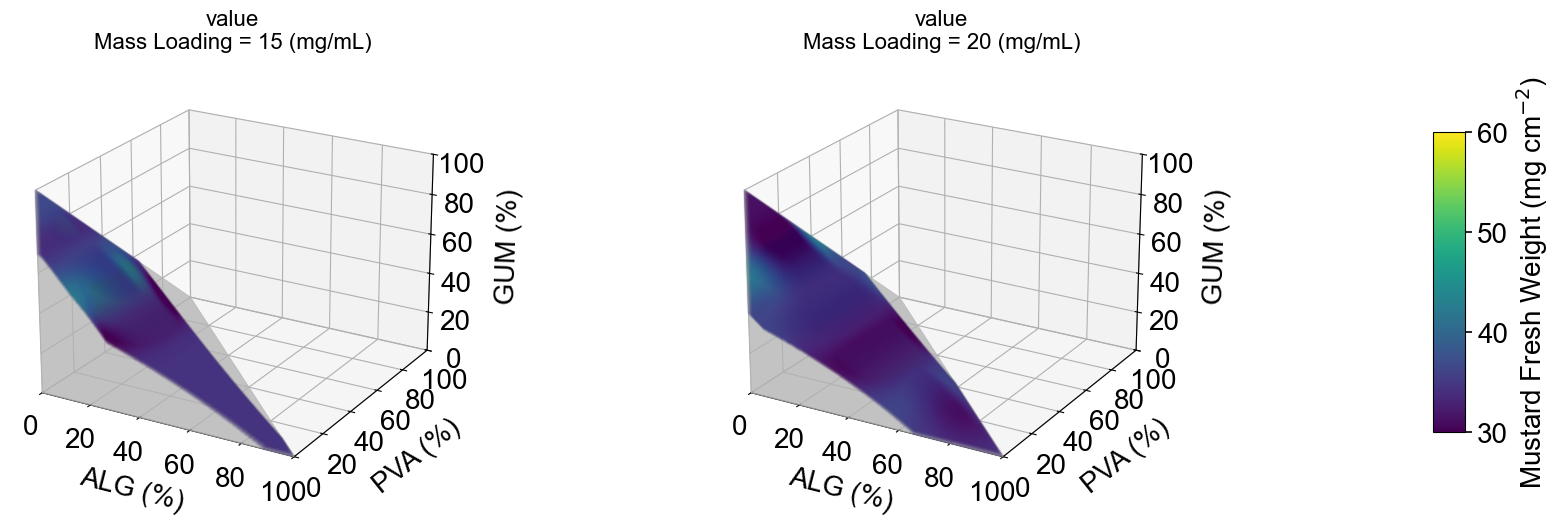

In [6]:
# GP mean 3-D -- 18pts (18 pts)
render_surface_3d(
    gp_mean_stage['18pts'], cmap='viridis', vmin=GP_VMIN, vmax=GP_VMAX,
    cbar_ticks=GP_TICKS,
    cbar_label=r'Mustard Fresh Weight (mg cm$^{-2}$)',
    fname='bo_gp_mean_18pts_3d_v7pub.svg',
    mark_max=False, mark_0608=False,
)

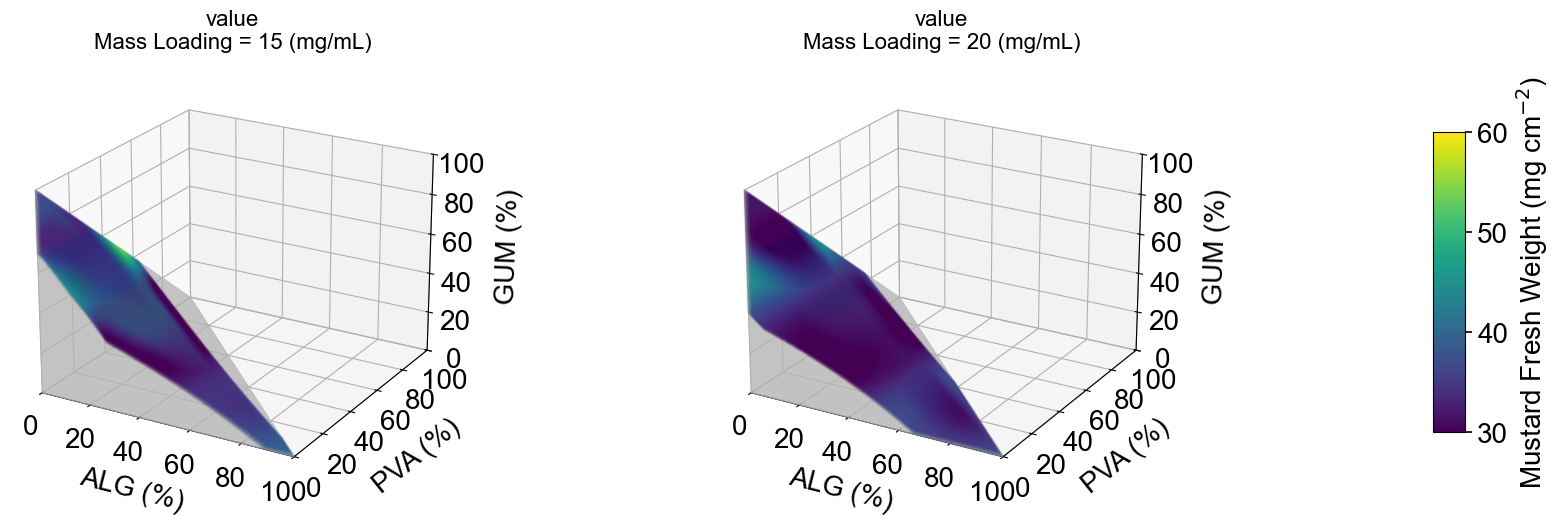

In [7]:
# GP mean 3-D -- 24pts (24 pts)
render_surface_3d(
    gp_mean_stage['24pts'], cmap='viridis', vmin=GP_VMIN, vmax=GP_VMAX,
    cbar_ticks=GP_TICKS,
    cbar_label=r'Mustard Fresh Weight (mg cm$^{-2}$)',
    fname='bo_gp_mean_24pts_3d_v7pub.svg',
    mark_max=False, mark_0608=False,
)

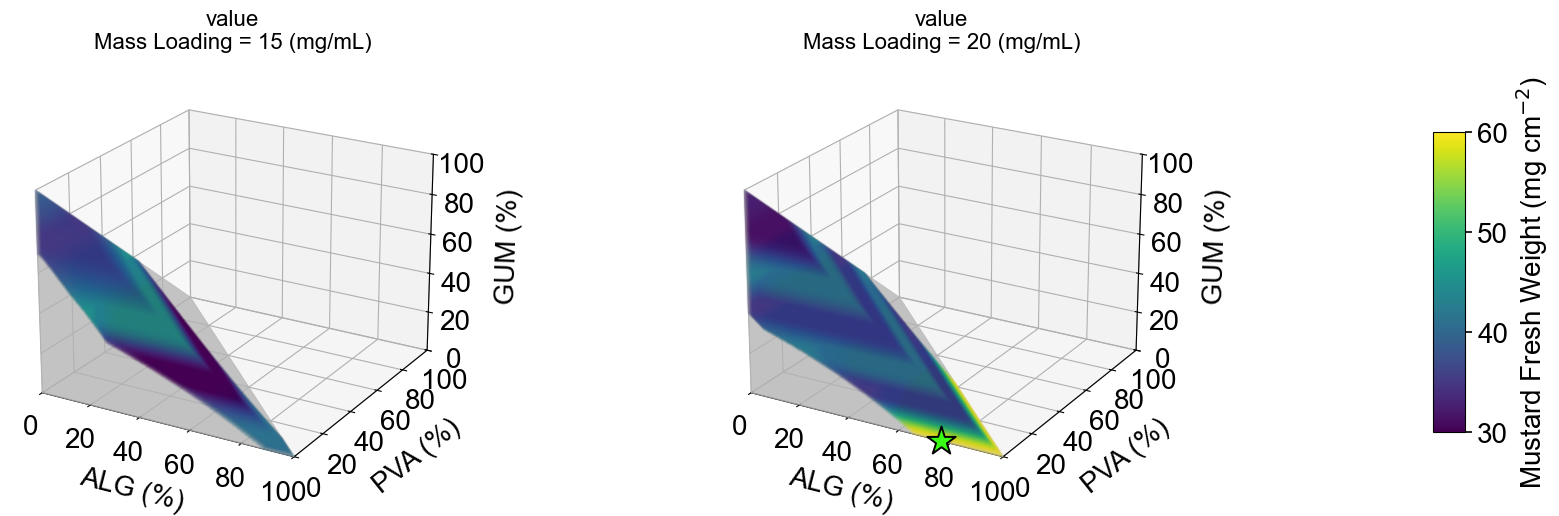

In [8]:
# GP mean 3-D -- 30pts (30 pts)
render_surface_3d(
    gp_mean_stage['30pts'], cmap='viridis', vmin=GP_VMIN, vmax=GP_VMAX,
    cbar_ticks=GP_TICKS,
    cbar_label=r'Mustard Fresh Weight (mg cm$^{-2}$)',
    fname='bo_gp_mean_30pts_3d_v7pub.svg',
    mark_max=False, mark_0608=True,
)

## UCB acquisition

In [ ]:
# UCB -- Initial stage (gp_init, beta=beta_R3) guides Round 3
def ucb_by_ml(gp, beta):
    out = {}
    for ml in MASS_LOADINGS:
        mu, std = gp.predict(grids_3d[ml], return_std=True)
        out[ml] = upper_confidence_bound(mu, std, beta=beta) * NORM_TO_MG
    return out

ucb_init = ucb_by_ml(gp_init, UCB_BETA_R3)
_u = np.concatenate(list(ucb_init.values()))
print(f"Init UCB (beta={UCB_BETA_R3}) range: [{_u.min():.1f}, {_u.max():.1f}] mg/cm^2 "
      f"(fixed scale [{UCB_VMIN}, {UCB_VMAX_INIT}])")

render_surface_3d(
    ucb_init, cmap='inferno', vmin=UCB_VMIN, vmax=UCB_VMAX_INIT, cbar_ticks=UCB_TICKS_INIT,
    cbar_label='Upper Confidence Bound (-)',
    fname='bo_ucb_init_3d_v7pub.svg',
    mark_max=False, mark_0608=False,
)

In [ ]:
# UCB -- Round-3 stage (gp_r3, beta=beta_R4) guides Round 4
ucb_r3 = ucb_by_ml(gp_r3, UCB_BETA_R4)
_u = np.concatenate(list(ucb_r3.values()))
print(f"R3 UCB (beta={UCB_BETA_R4}) range: [{_u.min():.1f}, {_u.max():.1f}] mg/cm^2 "
      f"(fixed scale [{UCB_VMIN}, {UCB_VMAX_R3}])")

render_surface_3d(
    ucb_r3, cmap='inferno', vmin=UCB_VMIN, vmax=UCB_VMAX_R3, cbar_ticks=UCB_TICKS_R3,
    cbar_label='Upper Confidence Bound (-)',
    fname='bo_ucb_r3_3d_v7pub.svg',
    mark_max=False, mark_0608=True,
)